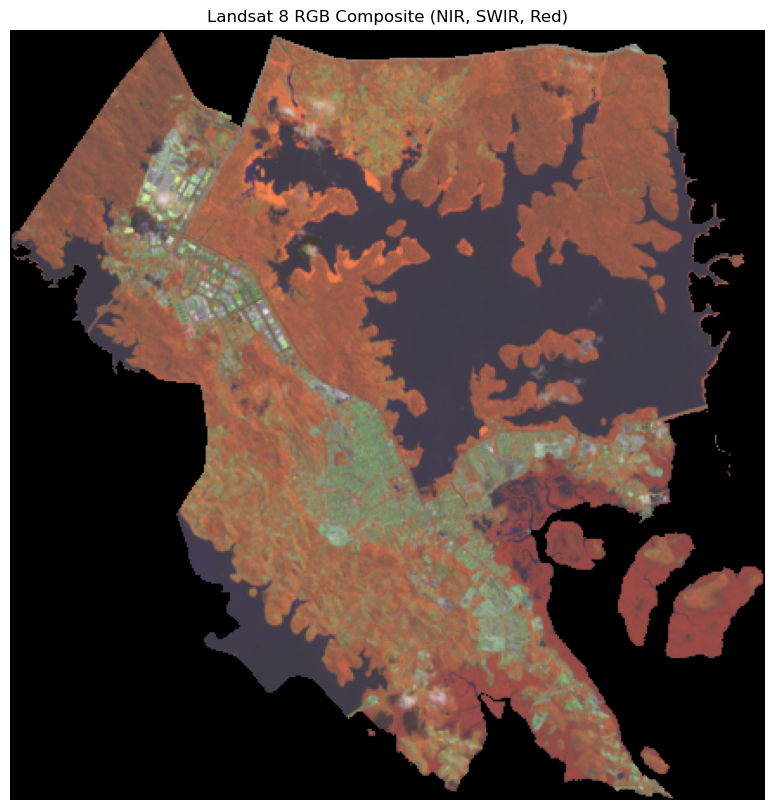

In [20]:
import os
import numpy as np
import geopandas as gpd
import rasterio as rio
from rasterio.plot import show
from rasterio.mask import mask
import matplotlib.pyplot as plt


kecamatan_utm = gpd.read_file('../data/boundaries/KOTA BATAM/kecamatan_utm.geojson')
bound = kecamatan_utm['NAMOBJ'] == 'Sei Beduk'

#read data landasat 8
lc08_path = '/Volumes/HOLMES/SATELLITE/landsat/20250706'
b1 = rio.open(f'{lc08_path}/LC09_L2SP_125059_20250706_20250707_02_T1_SR_B1.TIF')
b2 = rio.open(f'{lc08_path}/LC09_L2SP_125059_20250706_20250707_02_T1_SR_B2.TIF')
b3 = rio.open(f'{lc08_path}/LC09_L2SP_125059_20250706_20250707_02_T1_SR_B3.TIF')
b4 = rio.open(f'{lc08_path}/LC09_L2SP_125059_20250706_20250707_02_T1_SR_B4.TIF')
b5 = rio.open(f'{lc08_path}/LC09_L2SP_125059_20250706_20250707_02_T1_SR_B5.TIF')
b6 = rio.open(f'{lc08_path}/LC09_L2SP_125059_20250706_20250707_02_T1_SR_B6.TIF')
b7 = rio.open(f'{lc08_path}/LC09_L2SP_125059_20250706_20250707_02_T1_SR_B7.TIF')

#clip raster to kecamataan_utm (bound)
clip_b1, _ = mask(b1, kecamatan_utm[bound].geometry, crop=True)
clip_b2, _ = mask(b2, kecamatan_utm[bound].geometry, crop=True)
clip_b3, _ = mask(b3, kecamatan_utm[bound].geometry, crop=True)
clip_b4, _ = mask(b4, kecamatan_utm[bound].geometry, crop=True)
clip_b5, _ = mask(b5, kecamatan_utm[bound].geometry, crop=True)
clip_b6, _ = mask(b6, kecamatan_utm[bound].geometry, crop=True)
clip_b7, _ = mask(b7, kecamatan_utm[bound].geometry, crop=True)

#array to uint8
arr_b1 = clip_b1[0].astype('float32')
arr_b2 = clip_b2[0].astype('float32')
arr_b3 = clip_b3[0].astype('float32')
arr_b4 = clip_b4[0].astype('float32')
arr_b5 = clip_b5[0].astype('float32')
arr_b6 = clip_b6[0].astype('float32')
arr_b7 = clip_b7[0].astype('float32')

#normalize to 0-255
def normalize(arr):
    return (arr - arr.min()) / (arr.max() - arr.min()) * 255
norm_b1 = normalize(arr_b1).astype('uint8')
norm_b2 = normalize(arr_b2).astype('uint8')
norm_b3 = normalize(arr_b3).astype('uint8')
norm_b4 = normalize(arr_b4).astype('uint8')
norm_b5 = normalize(arr_b5).astype('uint8')
norm_b6 = normalize(arr_b6).astype('uint8')
norm_b7 = normalize(arr_b7).astype('uint8')

#compoosite RGB
rgb = np.dstack((norm_b5, norm_b6, norm_b4)).squeeze()  # Band 5 (NIR), Band 6 (SWIR), Band 4 (Red)
#plot RGB
plt.figure(figsize=(10, 10))
plt.imshow(rgb)
plt.title('Landsat 8 RGB Composite (NIR, SWIR, Red)')
plt.axis('off')
plt.show()
